In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Total transactions: 284807
Normal transactions: 284315
Fraudulent transactions: 492 (0.173%)


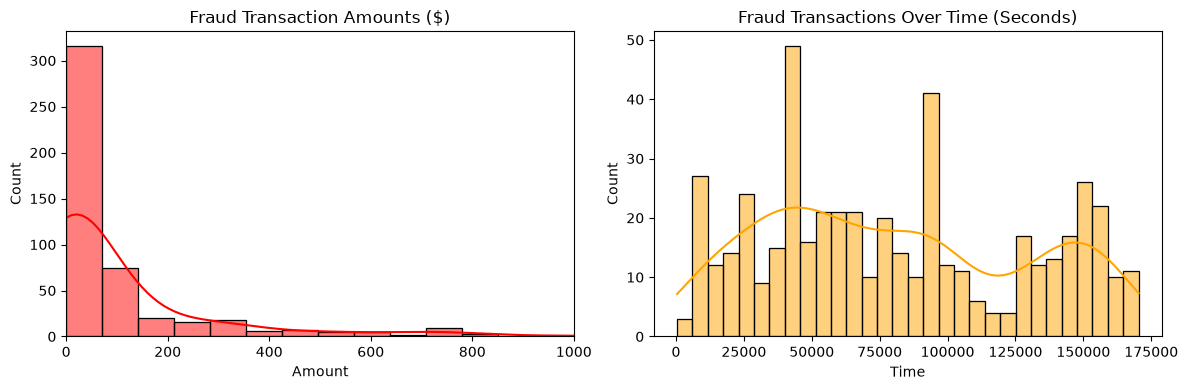

In [3]:
np.random.seed(42)
df['account_id'] = np.random.randint(1000, 1050, len(df))

normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

print(f"Total transactions: {len(df)}")
print(f"Normal transactions: {len(normal)}")
print(f"Fraudulent transactions: {len(fraud)} ({len(fraud)/len(df)*100:.3f}%)")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(fraud['Amount'], bins=30, color='red', kde=True)
plt.title('Fraud Transaction Amounts ($)')
plt.xlim(0, 1000)

plt.subplot(1, 2, 2)
sns.histplot(fraud['Time'], bins=30, color='orange', kde=True)
plt.title('Fraud Transactions Over Time (Seconds)')

plt.tight_layout()
plt.show()

In [5]:
conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, index=False, if_exists='replace')

query_bursts = """
    SELECT 
    account_id,
    COUNT(*) As total_transactions,
    SUM(Class) AS actual_frauds,
    ROUND(SUM(Amount), 2) AS total_spent
    FROM transactions
    GROUP BY account_id
    HAVING total_transactions > 5500
    ORDER BY total_transactions DESC
    LIMIT 5;
"""
query_high_value = """
    SELECT 
    account_id,
    Time,
    Amount,
    Class
    FROM transactions
    WHERE Amount > 2000
    ORDER BY Amount DESC
    LIMIT 5;
"""

print("--- SQL Alert 1: High-Frequency Transaction Bursts ---")
print(pd.read_sql(query_bursts, conn))

print("\n--- SQL Alert 2: High-Value Transactions ---")
print(pd.read_sql(query_high_value, conn))

--- SQL Alert 1: High-Frequency Transaction Bursts ---
   account_id  total_transactions  actual_frauds  total_spent
0        1037                5872              7    512121.59
1        1035                5830             10    491412.76
2        1015                5830             10    522865.27
3        1022                5808             13    517304.64
4        1047                5789              7    489307.56

--- SQL Alert 2: High-Value Transactions ---
   account_id      Time    Amount  Class
0        1040  166198.0  25691.16      0
1        1030   48401.0  19656.53      0
2        1026   95286.0  18910.00      0
3        1030   42951.0  12910.93      0
4        1040   46253.0  11898.09      0
